# Let's Train a Faster R-CNN model for food detection
The Faster R-CNN model will be trained on a COCO-formatted dataset.
It will detect the different food items in an image


In [37]:
import detectron2
from detectron2.engine import DefaultTrainer
from detectron2.config import get_cfg
from detectron2.model_zoo import get_config_file
from detectron2.data.datasets import register_coco_instances
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.evaluation import COCOEvaluator, inference_on_dataset
from detectron2.data import build_detection_test_loader
from detectron2.layers import ShapeSpec
from detectron2.modeling.roi_heads import FastRCNNOutputLayers #importing a new predictor
import os
import torch
import json

# Paths
data_dir = "/home/aojwang/data/Dataset"
train_images = "/home/aojwang/data/Dataset/images/"
train_annotations = os.path.join(data_dir, "coco_train.json")
val_images = "/home/aojwang/data/Dataset/images/OK 1"
val_annotations = os.path.join(data_dir, "coco_val.json")

# Register datasets
register_coco_instances("food_train", {}, train_annotations, train_images)
register_coco_instances("food_val", {}, val_annotations, val_images)

# Load class names from COCO JSON
with open(train_annotations, 'r') as f:
    coco_data = json.load(f)
    class_names = [category['name'] for category in coco_data['categories']]

# Set class names in metadata
MetadataCatalog.get("food_train").thing_classes = class_names
MetadataCatalog.get("food_val").thing_classes = class_names

# Custom trainer with evaluator
class TrainerWithEvaluator(DefaultTrainer):
    @classmethod
    def build_evaluator(cls, cfg, dataset_name, output_folder=None):
        if output_folder is None:
            output_folder = os.path.join(cfg.OUTPUT_DIR, "inference")
        return COCOEvaluator(dataset_name, cfg, False, output_folder)

# Configure Faster R-CNN
cfg = get_cfg()
cfg.merge_from_file(get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("food_train",)
cfg.DATASETS.TEST = ("food_val",) 
cfg.TEST.EVAL_PERIOD = 500  # Run evaluation every 500 iterations
cfg.DATALOADER.NUM_WORKERS = 4
cfg.MODEL.WEIGHTS = "detectron2://COCO-Detection/faster_rcnn_R_50_FPN_3x/137849458/model_final_280758.pkl"
cfg.SOLVER.IMS_PER_BATCH = 4
cfg.SOLVER.BASE_LR = 0.00025
cfg.SOLVER.MAX_ITER = 5000
cfg.SOLVER.STEPS = []  # No learning rate decay
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 512
cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(class_names)

# Train model
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
trainer = TrainerWithEvaluator(cfg)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
trainer.model.to(device)

num_inputs = trainer.model.roi_heads.box_predictor.cls_score.in_features

trainer.model.roi_heads.box_predictor = FastRCNNOutputLayers(
    input_shape=ShapeSpec(channels=num_inputs),
    num_classes=cfg.MODEL.ROI_HEADS.NUM_CLASSES,
    box2box_transform=trainer.model.roi_heads.box_predictor.box2box_transform
).to(device)

trainer.resume_or_load(resume=False)

trainer.train()

# Run evaluation after training
evaluator = COCOEvaluator("food_val", cfg, False, output_dir=cfg.OUTPUT_DIR)
val_loader = build_detection_test_loader(cfg, "food_val")
print("🔍 Running Evaluation...")
inference_on_dataset(trainer.model, val_loader, evaluator)


[03/13 10:57:18 d2.engine.defaults]: Model:
GeneralizedRCNN(
  (backbone): FPN(
    (fpn_lateral2): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral3): Conv2d(512, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output3): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral4): Conv2d(1024, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output4): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (fpn_lateral5): Conv2d(2048, 256, kernel_size=(1, 1), stride=(1, 1))
    (fpn_output5): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (top_block): LastLevelMaxPool()
    (bottom_up): ResNet(
      (stem): BasicStem(
        (conv1): Conv2d(
          3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
          (norm): FrozenBatchNorm2d(num_features=64, eps=1e-05)
        )
      )
      (res

Skip loading parameter 'roi_heads.box_predictor.cls_score.weight' to the model due to incompatible shapes: (81, 1024) in the checkpoint but (248, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.cls_score.bias' to the model due to incompatible shapes: (81,) in the checkpoint but (248,) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.weight' to the model due to incompatible shapes: (320, 1024) in the checkpoint but (988, 1024) in the model! You might want to double check if this is expected.
Skip loading parameter 'roi_heads.box_predictor.bbox_pred.bias' to the model due to incompatible shapes: (320,) in the checkpoint but (988,) in the model! You might want to double check if this is expected.
Some model parameters or buffers are not found in the checkpoint:
roi_heads.box_predictor.bbox_pred.{bias, weight}
roi_heads.box_predictor.cls_score.{

[03/13 10:57:18 d2.engine.train_loop]: Starting training from iteration 0
[03/13 10:57:26 d2.utils.events]:  eta: 0:30:18  iter: 19  total_loss: 5.84  loss_cls: 5.614  loss_box_reg: 0.1932  loss_rpn_cls: 0.007344  loss_rpn_loc: 0.01103    time: 0.3620  last_time: 0.3628  data_time: 0.0844  last_data_time: 0.0090   lr: 4.9953e-06  max_mem: 11058M
[03/13 10:57:34 d2.utils.events]:  eta: 0:30:20  iter: 39  total_loss: 5.8  loss_cls: 5.592  loss_box_reg: 0.187  loss_rpn_cls: 0.01022  loss_rpn_loc: 0.008856    time: 0.3635  last_time: 0.3827  data_time: 0.0224  last_data_time: 0.0122   lr: 9.9902e-06  max_mem: 11058M
[03/13 10:57:41 d2.utils.events]:  eta: 0:30:04  iter: 59  total_loss: 5.716  loss_cls: 5.502  loss_box_reg: 0.1714  loss_rpn_cls: 0.01295  loss_rpn_loc: 0.01293    time: 0.3591  last_time: 0.3432  data_time: 0.0123  last_data_time: 0.0090   lr: 1.4985e-05  max_mem: 11058M
[03/13 10:57:48 d2.utils.events]:  eta: 0:29:56  iter: 79  total_loss: 5.629  loss_cls: 5.412  loss_box_re

OrderedDict([('bbox',
              {'AP': 5.800722386875226,
               'AP50': 16.633496925993274,
               'AP75': 1.4867391911604955,
               'APs': nan,
               'APm': nan,
               'APl': 5.800722386875226,
               'AP-Beans': nan,
               'AP-Orange Juice': nan,
               'AP-Cola': nan,
               'AP-Fanta': nan,
               'AP-Apple juice': nan,
               'AP-Energy Drink': nan,
               'AP-Coffee': nan,
               'AP-Cola Sugarless': nan,
               'AP-Carbonated Sprite': nan,
               'AP-Broth': nan,
               'AP-Carbonated Coke': nan,
               'AP-Olive Oil': nan,
               'AP-Sunflower Seeds': 0.0,
               'AP-Sesame Seeds': 13.861386138613863,
               'AP-Pumpkin Seeds': 50.0,
               'AP-Poppy Seeds': 3.0000000000000004,
               'AP-Peanut': 0.0,
               'AP-Mozzarella': nan,
               'AP-Macadamia': 0.0,
               'AP-Haz

In [36]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import ToTensor
import json
from torch.utils.data import DataLoader
from torchvision.datasets import CocoDetection

# Load class names from JSON
json_path = "/home/aojwang/data/Dataset/coco_train.json"
with open(json_path, "r") as f:
    coco_data = json.load(f)
    class_names = [category["name"] for category in coco_data["categories"]]

num_classes = len(class_names) + 1  # Add 1 for background class

# Load pre-trained Faster R-CNN
model = torchvision.models.detection.fasterrcnn_resnet50_fpn(pretrained=True)

# Replace classifier with a new one
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

# Move model to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define transformations
transform = ToTensor()

# Load Training and Validation datasets
train_dataset = CocoDetection(root="/home/aojwang/data/Dataset/images/", 
                              annFile=json_path, 
                              transform=transform)

val_dataset = CocoDetection(root="/home/aojwang/data/Dataset/images/OK 1", 
                            annFile="/home/aojwang/data/Dataset/coco_val.json", 
                            transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

# Define optimizer and learning rate
optimizer = torch.optim.Adam(model.parameters(), lr=0.00025)

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    for images, targets in train_loader:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

    # Validation step
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, targets in val_loader:
            images = [img.to(device) for img in images]
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

            loss_dict = model(images, targets)
            val_loss += sum(loss for loss in loss_dict.values()).item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {losses.item()}, Val Loss: {val_loss/len(val_loader)}")

# Save the trained model
torch.save(model.state_dict(), "food_detector.pth")


Total Classes in Dataset: 247
Configured Number of Classes: 247


In [11]:
from PIL import Image
image_path = "/home/aojwang/data/Dataset/images/OK 3b/1AppleJuice.JPG"
image = Image.open(image_path)
image = image.convert("RGB")  # Ensure EXIF is ignored
image.save(image_path)  # Overwrite the image without EXIF metadata


Fixed: /home/aojwang/data/Dataset/images/OK 4/2Weetabix.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/5Chicken.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/3Lambstew.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/1BrownUgalimillet.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/3Omena.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/2Chickenpeas.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/2Ndengu.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/3Matumbofried.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/1Ndengu.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/4Blackbeans.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/2Whitebutternutbeans.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/3Githeri.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/2Plumtomatoes.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/5BrownUgalimillet.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/4Meatballs.JPG
Fixed: /home/aojwang/data/Dataset/images/OK 4/1Mbaazi.JPG
Fixed: /ho

# Image augmentation

In [ ]:
import cv2
import json
import numpy as np
import albumentations as A
from pycocotools.coco import COCO
from albumentations.pytorch import ToTensorV2


# Load COCO JSON Annotations
coco_path = "/home/aojwang/data/Dataset/coco.json"
with open(coco_path, "r") as f:
    coco_data = json.load(f)

# Initialize COCO API
coco = COCO(coco_path)

# Define Augmentations
transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.GaussianBlur(p=0.2),
    A.RandomScale(scale_limit=0.2, p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=20, p=0.5),
], bbox_params=A.BboxParams(format="coco", label_fields=["category_id"]))

# Process Each Image In-Memory
augmented_images = []
for img_info in coco_data["images"]:
    img_id = img_info["id"]
    img_path = f"/home/aojwang/data/MergeDataset/images/{img_info['file_name']}"  # Adjust path if necessary
    image = cv2.imread(img_path)
    
    if image is None:
        continue
    
    # Get Annotations for this Image
    ann_ids = coco.getAnnIds(imgIds=[img_id])
    annotations = coco.loadAnns(ann_ids)

    # Extract Bounding Boxes & Categories
    bboxes = []
    category_ids = []
    for ann in annotations:
        bbox = ann["bbox"]  # COCO format: [x, y, width, height]
        bboxes.append(bbox)
        category_ids.append(ann["category_id"])

    # Apply Augmentations
    transformed = transform(image=image, bboxes=bboxes, category_id=category_ids)
    aug_img = transformed["image"]
    aug_bboxes = transformed["bboxes"]

    # Store Augmented Image and Annotations
    augmented_images.append({
        "image": aug_img,
        "bboxes": aug_bboxes,
        "category_ids": category_ids,
    })

def visualize_augmented_images(augmented_images, num_images=5):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i, aug_data in enumerate(augmented_images[:num_images]):
        image = aug_data["image"]
        bboxes = aug_data["bboxes"]
        category_ids = aug_data["category_ids"]

        # Convert from OpenCV (BGR) to Matplotlib (RGB)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ax = axes[i]
        ax.imshow(image)
        ax.set_title(f"Augmented Image {i+1}")

        # Draw bounding boxes
        for bbox in bboxes:
            x, y, w, h = bbox
            rect = patches.Rectangle(
                (x, y), w, h, linewidth=2, edgecolor="r", facecolor="none"
            )
            ax.add_patch(rect)

        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Call the function to visualize
visualize_augmented_images(augmented_images)

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


## Let's visualize the model's performance over epochs

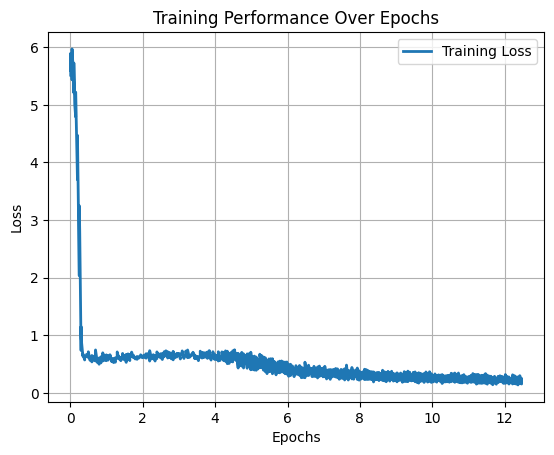

In [17]:
import json
import matplotlib.pyplot as plt

# Path to Detectron2 metrics log file
log_file = "output/metrics.json"

# Lists to store training and validation loss
iterations, loss_values, val_loss_values = [], [], []

with open(log_file, "r") as f:
    for line in f:
        log = json.loads(line)
        if "total_loss" in log:  # Training loss
            iterations.append(log["iteration"])
            loss_values.append(log["total_loss"])
        if "validation_loss" in log:  # Validation loss (if available)
            val_loss_values.append(log["validation_loss"])

# Ensure unique, sorted iterations for cleaner plots
sorted_pairs = sorted(set(zip(iterations, loss_values)))
sorted_iterations, sorted_losses = zip(*sorted_pairs)

# Convert iterations to epochs (Adjust iterations_per_epoch)
iterations_per_epoch = 401  # Change based on dataset size & batch size
epochs = [it / iterations_per_epoch for it in sorted_iterations]

# Plot training loss
plt.plot(epochs, sorted_losses, label="Training Loss", linewidth=2)

# If validation loss is available, plot it
if val_loss_values:
    plt.plot(epochs[:len(val_loss_values)], val_loss_values, label="Validation Loss", linestyle="dashed", linewidth=2)

# Plot formatting
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Performance Over Epochs")
plt.legend()
plt.grid(True)
plt.show()


## Image augmentation

In [ ]:
# ! pip install albumentations opencv-python numpy
import cv2
import numpy as np
import albumentations as A
import os

def load_yolo_annotations(txt_path):
    """Load YOLO annotations from a .txt file."""
    boxes = []
    with open(txt_path, "r") as f:
        for line in f.readlines():
            values = line.strip().split()
            class_id = int(values[0])
            x_center, y_center, width, height = map(float, values[1:])
            boxes.append([x_center, y_center, width, height, class_id])
    return boxes

def save_yolo_annotations(txt_path, boxes):
    """Save YOLO annotations to a .txt file."""
    with open(txt_path, "w") as f:
        for box in boxes:
            f.write(f"{int(box[4])} {box[0]} {box[1]} {box[2]} {box[3]}\n")

def augment_image(image, bboxes):
    """Perform augmentations while skipping invalid ones."""
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        A.VerticalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        A.Affine(scale=(0.95, 1.05), translate_percent=(-0.05, 0.05), rotate=(-10, 10), p=0.5)
    ], bbox_params=A.BboxParams(format='yolo', label_fields=[]))

    try:
        transformed = transform(image=image, bboxes=[b[:4] for b in bboxes])

        # Check if any bounding box is invalid
        for bbox in transformed["bboxes"]:
            if any(coord < 0 or coord > 1 for coord in bbox):
                print("Skipping augmentation due to invalid bbox:", bbox)
                return image, bboxes

        return transformed["image"], transformed["bboxes"]

    except Exception as e:
        print("Error during augmentation:", e)
        return image, bboxes  # Skip and return original data

def augment_dataset(original_images_dir, original_labels_dir):
    """Augment dataset and save only the augmented images and labels."""
    image_files = [f for f in os.listdir(original_images_dir) if f.endswith(('.jpg', '.JPG'))]

    for img_file in image_files:
        img_path = os.path.join(original_images_dir, img_file)
        label_path = os.path.join(original_labels_dir, img_file.replace('.jpg', '.txt').replace('.JPG', '.txt'))
        
        if not os.path.exists(label_path):
            continue

        image = cv2.imread(img_path)

        # Load YOLO bounding boxes (normalized values)
        boxes = load_yolo_annotations(label_path)

        # Generate and save augmented image and annotations
        augmented_image, augmented_boxes = augment_image(image, boxes)

        # Preserve original class labels
        aug_boxes = [b + [boxes[i][4]] for i, b in enumerate(augmented_boxes)]

        # Save augmented image and label
        aug_img_name = f"aug_{img_file}"
        aug_label_name = f"aug_{img_file.replace('.jpg', '.txt').replace('.JPG', '.txt')}"
        cv2.imwrite(os.path.join(original_images_dir, aug_img_name), augmented_image)
        save_yolo_annotations(os.path.join(original_labels_dir, aug_label_name), aug_boxes)

# Define dataset directories
original_images_dir = "/home/aojwang/data/yolo_dataset/val/images"
original_labels_dir = "/home/aojwang/data/yolo_dataset/val/labels"

# Process and save the augmented dataset
augment_dataset(original_images_dir, original_labels_dir)

## Visualize augmented images

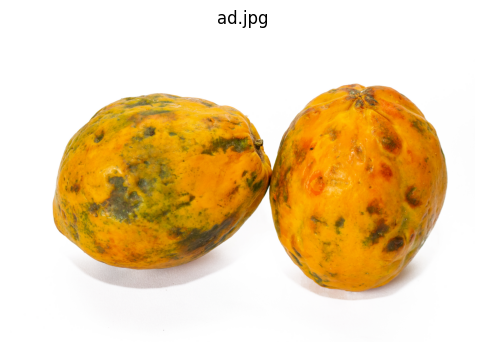

In [2]:
# visualize images
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load and display the image
image_path = "/home/aojwang/data/DrOjwang/Day 1/ad .jpg"
img = mpimg.imread(image_path)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title('ad.jpg')
plt.show()


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import random

# Define dataset directories
image_dir = "/home/aojwang/data/yolo_dataset/val/images"
label_dir = "/home/aojwang/data/yolo_dataset/val/labels"

# Dynamically list all images starting with "aug_"
augmented_images = [img for img in os.listdir(image_dir) if img.startswith("aug_")]

# Count total images and labels
total_images = len(os.listdir(image_dir))
total_labels = len(os.listdir(label_dir))
total_augmented = len(augmented_images)

print(f"Total Images: {total_images}")
print(f"Total Labels: {total_labels}")
print(f"Total Augmented Images: {total_augmented}")

# Choose a random augmented image for visualization
if total_augmented == 0:
    print("No augmented images found.")
else:
    random_image = random.choice(augmented_images)
    image_path = os.path.join(image_dir, random_image)
    
    # Handle different file extensions
    label_path = os.path.join(label_dir, random_image.rsplit(".", 1)[0] + ".txt")

    # Function to read YOLO annotations
    def read_yolo_annotations(txt_file):
        boxes = []
        if not os.path.exists(txt_file):
            print(f"Warning: Label file not found for {random_image}")
            return boxes
        with open(txt_file, "r") as f:
            for line in f:
                values = line.strip().split()
                class_id = int(values[0])
                x_center, y_center, width, height = map(float, values[1:])
                boxes.append((class_id, x_center, y_center, width, height))
        return boxes

    # Read image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for display

    # Read bounding boxes
    bboxes = read_yolo_annotations(label_path)
    h, w, _ = image.shape  # Get image dimensions

    # Draw bounding boxes
    for class_id, x_center, y_center, width, height in bboxes:
        x1 = int((x_center - width / 2) * w)
        y1 = int((y_center - height / 2) * h)
        x2 = int((x_center + width / 2) * w)
        y2 = int((y_center + height / 2) * h)

        # Draw rectangle and label
        cv2.rectangle(image, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(image, f"Class {class_id}", (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    # Display the image with bounding boxes
    plt.figure(figsize=(10, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Augmented Image: {random_image}")
    plt.show()


# Train yolo model

In [78]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
results = model.train(data="/home/aojwang/data/yolo_dataset/yolo.yaml",epochs=10, batch=4, imgsz=640, project='runs/train', name='aug_food_detection')

New https://pypi.org/project/ultralytics/8.3.157 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.69 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A10G, 22836MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/home/aojwang/data/yolo_dataset/yolo.yaml, epochs=10, time=None, patience=100, batch=4, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/train, name=aug_food_detection14, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=Fals

train: Scanning /opt/dlami/nvme/aojwang/yolo_dataset/train/labels... 9652 images, 640 backgrounds, 0 corrupt: 100%|██████████| 9652/9


train: New cache created: /opt/dlami/nvme/aojwang/yolo_dataset/train/labels.cache
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))


val: Scanning /opt/dlami/nvme/aojwang/yolo_dataset/val/labels... 2758 images, 188 backgrounds, 0 corrupt: 100%|██████████| 2758/2758 


val: New cache created: /opt/dlami/nvme/aojwang/yolo_dataset/val/labels.cache
Plotting labels to runs/train/aug_food_detection14/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=3.7e-05, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/train/aug_food_detection14
Starting training for 10 epochs...
Closing dataloader mosaic
albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, num_output_channels=3, method='weighted_average'), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all       2758       4142       0.56      0.112     0.0922     0.0671

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


      10/10      1.16G      1.452      4.302      1.666          6        640: 100%|██████████| 2413/2413 [04:09<00:00,  9.68it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 345/345 [01:04<00:00,  5.3


                   all       2758       4142      0.572      0.108     0.0968     0.0712

10 epochs completed in 0.889 hours.
Optimizer stripped from runs/train/aug_food_detection14/weights/last.pt, 7.0MB
Optimizer stripped from runs/train/aug_food_detection14/weights/best.pt, 7.0MB

Validating runs/train/aug_food_detection14/weights/best.pt...
Ultralytics 8.3.69 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A10G, 22836MiB)
Model summary (fused): 168 layers, 3,390,416 parameters, 0 gradients, 9.9 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 345/345 [00:58<00:00,  5.9


                   all       2758       4142      0.576      0.108     0.0968     0.0712
                 Beans         15         15          0          0    0.00222     0.0015
          Orange Juice          9          9          0          0          0          0
                  Cola          4          4          1          0          0          0
                 Fanta          1          1          1          0          0          0
           Apple juice          4          4          1          0     0.0159     0.0127
          Energy Drink          2          2          0          0          0          0
                Coffee          2          2          0          0          0          0
        Cola Sugarless          1          1          1          0          0          0
     Carbonated Sprite          3          3          1          0          0          0
                 Broth          1          1          1          0          0          0
       Carbonated Cok

In [3]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
# yolo model trained without augmented images
results = model.train(data="/home/aojwang/data/yolo_dataset/yolo.yaml",epochs=100, batch=8, imgsz=640, project='runs/train', name='food_detection')

New https://pypi.org/project/ultralytics/8.3.91 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.69 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A10G, 22836MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/home/aojwang/data/yolo_dataset/yolo.yaml, epochs=100, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=runs/train, name=food_detection13, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, e

train: Scanning /opt/dlami/nvme/aojwang/Dataset/labels/DRINKS BATCH... 1770 images, 10 backgrounds, 0 corrupt: 100%|████

train: New cache created: /opt/dlami/nvme/aojwang/Dataset/labels/DRINKS BATCH.cache



val: Scanning /opt/dlami/nvme/aojwang/Dataset/labels/DRINKS BATCH.cache... 1770 images, 10 backgrounds, 0 corrupt: 100%|


Plotting labels to runs/train/food_detection13/labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=4e-05, momentum=0.9) with parameter groups 57 weight(decay=0.0), 64 weight(decay=0.0005), 63 bias(decay=0.0)
TensorBoard: model graph visualization added ✅
Image sizes 640 train, 640 val
Using 8 dataloader workers
Logging results to runs/train/food_detection13
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all       1770       2669      0.806      0.794      0.865      0.747

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


    100/100      1.81G     0.7484      1.489      1.175          5        640: 100%|██████████| 222/222 [00:19<00:00, 11
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 111/111 [00:1


                   all       1770       2669      0.804      0.792      0.867       0.75

100 epochs completed in 1.029 hours.
Optimizer stripped from runs/train/food_detection13/weights/last.pt, 7.0MB
Optimizer stripped from runs/train/food_detection13/weights/best.pt, 7.0MB

Validating runs/train/food_detection13/weights/best.pt...
Ultralytics 8.3.69 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A10G, 22836MiB)
Model summary (fused): 168 layers, 3,385,265 parameters, 0 gradients, 9.9 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 111/111 [00:1


                   all       1770       2669      0.855      0.768      0.878      0.761
                 Beans         18         18          1      0.302      0.594      0.501
          Orange Juice          6          6      0.299      0.333      0.308      0.221
                  Cola          4          4      0.631          1      0.995      0.871
                 Fanta          3          3          1          0      0.863      0.704
           Apple juice          6          6      0.437          1      0.757      0.469
          Energy Drink          1          1          1          0      0.142      0.128
                Coffee          1          1          1          0      0.995      0.895
        Cola Sugarless          2          2      0.365        0.5      0.448      0.388
     Carbonated Sprite          3          3      0.434      0.667      0.472      0.434
                 Broth          1          1      0.824          1      0.995      0.895
       Carbonated Cok

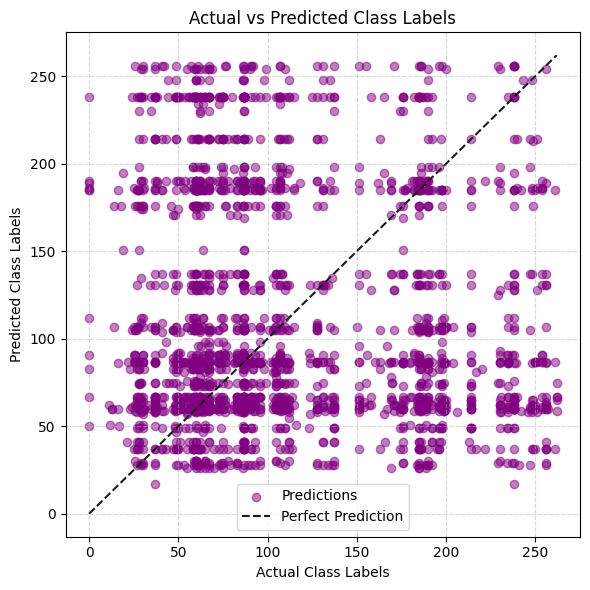

In [79]:
from ultralytics import YOLO
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt

# Load the trained YOLO model
model = YOLO("/home/aojwang/data/model/model/CarboAI/runs/train/aug_food_detection14/weights/best.pt")

# Load all image paths (case-insensitive JPG/JPEG)
image_paths = glob('/home/aojwang/data/yolo_dataset/val/images/*')
image_paths = [p for p in image_paths if p.lower().endswith(('.jpg'))]

actual_classes = []
predicted_classes = []

for img_path in image_paths:
    # Check for corresponding label
    label_path = img_path.replace('images', 'labels')
    label_path = os.path.splitext(label_path)[0] + '.txt'
    
    if not os.path.exists(label_path):
        continue  # skip image if no label

    results = model(img_path, verbose=False)

    for r in results:
        if len(r.boxes) > 0:
            preds = r.boxes.cls.cpu().numpy().astype(int)
            predicted_classes.extend(preds)

            with open(label_path, 'r') as f:
                lines = f.readlines()
                targets = [int(line.split()[0]) for line in lines]
                actual_classes.extend(targets)

# Truncate both lists to the shortest length
min_len = min(len(actual_classes), len(predicted_classes))
actual_classes = actual_classes[:min_len]
predicted_classes = predicted_classes[:min_len]

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(actual_classes, predicted_classes, alpha=0.5, color='purple', label='Predictions')

# Dotted y = x reference line
max_val = max(max(actual_classes), max(predicted_classes))
min_val = min(min(actual_classes), min(predicted_classes))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')

# Labels and title
plt.xlabel("Actual Class Labels")
plt.ylabel("Predicted Class Labels")
plt.title("Actual vs Predicted Class Labels")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


# Validate yolo model

In [4]:
from ultralytics import YOLO

# Load a model
model = YOLO("/home/aojwang/data/model/model/runs/train/aug_food_detection6/weights/best.pt")

# Validate the model
metrics = model.val(data='/home/aojwang/data/yolo_dataset/yolo.yaml', project='runs/val', save_json=True)

Ultralytics 8.3.69 🚀 Python-3.10.12 torch-2.5.1+cu124 CUDA:0 (NVIDIA A10G, 22836MiB)
Model summary (fused): 168 layers, 3,390,416 parameters, 0 gradients, 9.9 GFLOPs


val: Scanning /opt/dlami/nvme/aojwang/yolo_dataset/val/labels.cache... 718 images, 50 backgrounds, 0 corrupt: 100%|██████████| 718/71
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 45/45 [00:17<00:00,  2.61i


                   all        718       1113      0.566      0.359      0.374      0.289
                 Beans          6          6          0          0    0.00691    0.00542
          Orange Juice          2          2          1          0      0.995      0.799
           Apple juice          1          1      0.133          1      0.199      0.159
     Carbonated Sprite          1          1          1          0          0          0
             Olive Oil          1          1       0.36          1      0.995      0.796
       Sunflower Seeds          1          1          1          0     0.0332     0.0332
          Sesame Seeds          2          2          1          0          0          0
         Pumpkin Seeds          2          2          1          0    0.00826    0.00661
           Poppy Seeds          1          1          1          0     0.0321     0.0257
                Peanut          1          1          1          0      0.995      0.697
            Mozzarell

# Visualize annotations

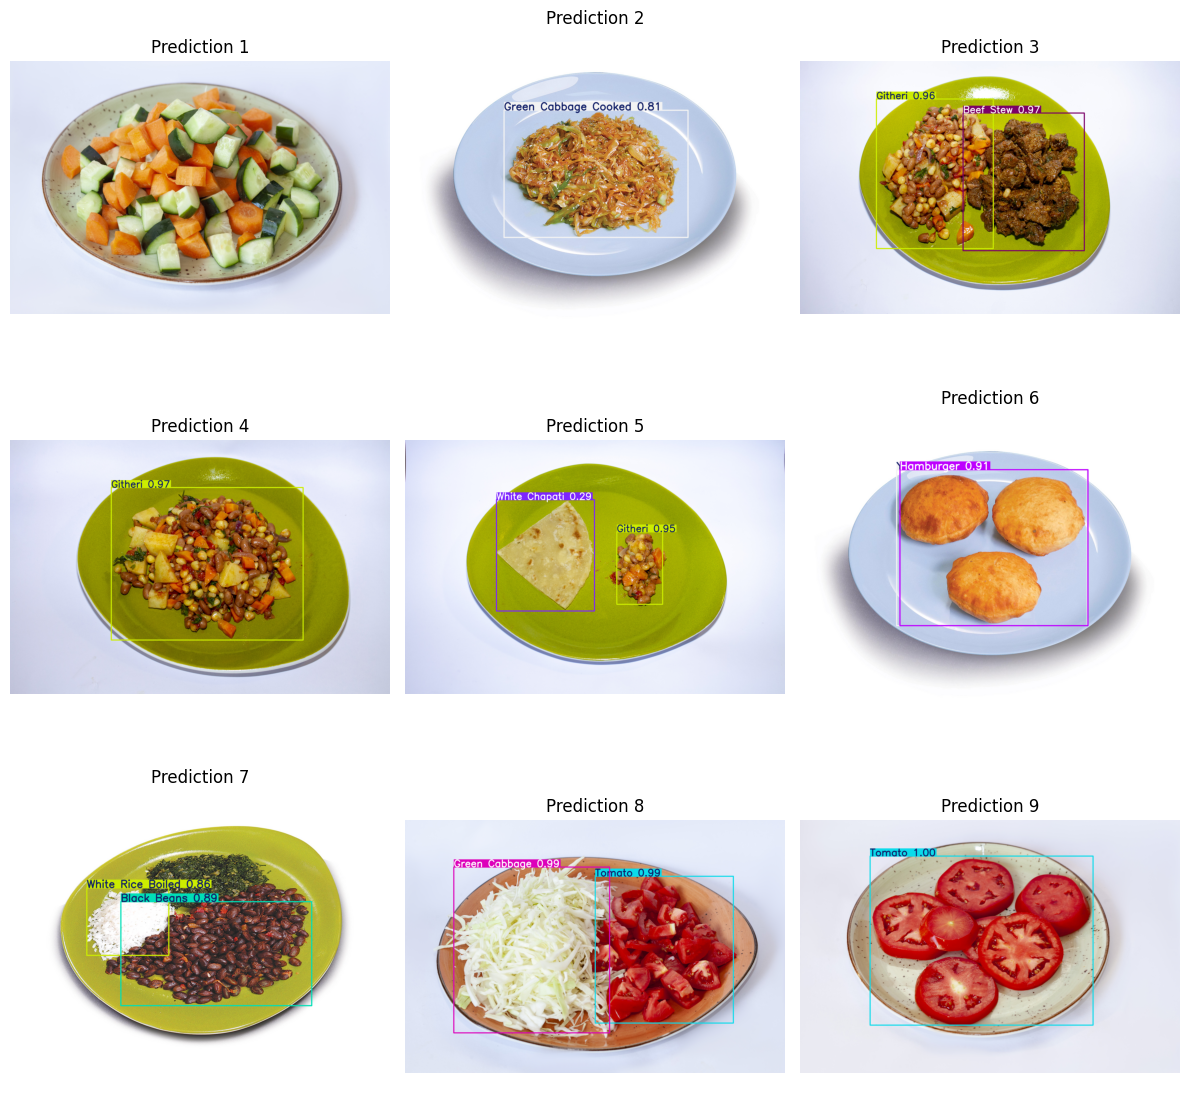

In [36]:
import os
import random
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load YOLO model
model = YOLO("/home/aojwang/data/model/model/CarboAI/runs/train/aug_food_detection13/weights/best.pt")

# Path to image directory
image_dir = "/home/aojwang/data/MergeDataset/images"
all_images = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.lower().endswith((".jpg", ".JPG",))]

# Select 9 random images
sample_images = random.sample(all_images, 9)

# Run batched inference
results = model(sample_images, verbose=False)

# Create 3x3 grid for displaying results
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

# Show each result directly using .plot()
for i, result in enumerate(results):
    annotated_img = result.plot()  
    axes[i].imshow(annotated_img[..., ::-1])
    axes[i].axis('off')
    axes[i].set_title(f"Prediction {i+1}")

plt.tight_layout()
plt.show()


#  Load YOLOv8 for Food Recognition & Extraction

In [37]:
import torch
import cv2
import numpy as np
import pandas as pd
import torchvision.transforms as transforms
from torchvision import models
import torch.nn as nn
from ultralytics import YOLO
from fuzzywuzzy import process

# --- Model + Data Setup ---
YOLO_MODEL_PATH = "/home/aojwang/data/model/model/CarboAI/runs/train/aug_food_detection13/weights/best.pt"
CSV_FILE = "/home/aojwang/data/MergeDataset/csv_files/found_merged.csv"
MODEL_SAVE_PATH = "/home/aojwang/data/model/model/CarboAI/food_weight_model.pth"

# Load YOLOv8
yolo_model = YOLO(YOLO_MODEL_PATH)

# Load and clean CSV
df = pd.read_csv(CSV_FILE)
df.columns = df.columns.str.strip().str.replace("\n", " ").str.replace("  ", " ")
df["LABELS"] = df["LABELS"].astype(str).str.lower().str.strip()


# --- Define Weight Estimation Model ---
class WeightEstimationModel(nn.Module):
    """
    A regression model that uses pretrained MobileNetV3 features and additional
    geometric and intensity-based features to estimate food weight from images.
    Args:
        feature_dim (int): Number of additional handcrafted features to concatenate.
    """
    def __init__(self, feature_dim=3):
        super(WeightEstimationModel, self).__init__()
        self.mobilenet = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.IMAGENET1K_V1)
        self.mobilenet.classifier = nn.Identity()
        self.fc = nn.Sequential(
            nn.Linear(960 + feature_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.ReLU()
        )

    def forward(self, image, additional_features):
        """
        Forward pass through the model.

        Args:
            image (torch.Tensor): Preprocessed image tensor [1, 3, 224, 224].
            additional_features (torch.Tensor): Handcrafted features tensor [1, feature_dim].

        Returns:
            torch.Tensor: Estimated food weight [1].
        """
        image_features = self.mobilenet(image)
        combined = torch.cat((image_features, additional_features), dim=1)
        return self.fc(combined)


#--- Load model to device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weight_model = WeightEstimationModel().to(device)


# --- Get food carbohydrate content ---
def get_food_carbs(image_path, detected_label):
    """
    Uses fuzzy matching to retrieve the carbohydrate content from the CSV file.

    Args:
        image_path (str): Full path to the image.
        detected_label (str): Detected label from YOLO.

    Returns:
        float or None: Corresponding carbohydrate content in grams or None if not found.
    """
    detected_label = detected_label.lower().strip()
    image_data = df[df["ospath"] == image_path]

    if image_data.empty:
        print(f"⚠️ No CSV match for image {image_path}")
        return None

    all_labels = image_data["LABELS"].dropna().unique()
    best_match, score = process.extractOne(detected_label, all_labels)

    if score < 80:
        print(f"⚠️ Poor match for {detected_label} in {image_path} (Score: {score})")
        return None

    carb_col = df.columns[3]
    carbs = image_data.loc[image_data["LABELS"] == best_match, carb_col]

    if not carbs.empty:
        print(f"✅ Matched {detected_label} -> {best_match} ({float(carbs.iloc[0])}g carbs)")
        return float(carbs.iloc[0])

    return None


#--- Preprocess image for training/ prediction ---
def preprocess_image(image_path, use_ground_truth=True):
    """
    1. Detects food using YOLOv8
    2. Extracts bounding box features (area, aspect ratio, pixel intensity)
    3. Crops detected food item for MobileNetV3
    4. Retrieves the corresponding carbohydrate weight from the CSV
    
    Args:
        image_path (str): Path to the input image.
        use_ground_truth : bool
            If True, retrieves true weight from CSV for each detected item. Use for training.
            If False, skips weight lookup. Use for inference.

    Returns:
        list: Tuples of (label, image_tensor, additional_features, weight or None).
    """
    print(f"\n📷 Processing: {image_path}")
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Error: Cannot read {image_path}")
        return []

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    results = yolo_model(image, verbose=False)
    detections = results[0].boxes
    if len(detections) == 0:
        print("⚠️ No food detected.")
        return []

    img_h, img_w = image.shape[:2]
    image_area = img_h * img_w

    food_data = []
    for box in detections:
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        label = yolo_model.names[int(box.cls[0].item())]
        print(f"🧭 Detected: {label}")
        cropped = image[y1:y2, x1:x2]
        if cropped.shape[0] == 0 or cropped.shape[1] == 0:
            print(f"⚠️ Invalid crop for {label}")
            continue

        h, w = cropped.shape[:2]

        # Handcrafted features
        area = h * w
        aspect_ratio = w / (h + 1e-5)
        intensity = np.mean(cropped)

        # 🔄 Normalization
        norm_area = area / image_area
        norm_aspect_ratio = aspect_ratio
        norm_intensity = intensity / 255.0

        # Image preprocessing for CNN
        transform = transforms.Compose([
            transforms.ToPILImage(),
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
        img_tensor = transform(cropped).unsqueeze(0).to(device)

        # Final feature tensor
        features = torch.tensor(
            [norm_area, norm_aspect_ratio, norm_intensity],
            dtype=torch.float32
        ).unsqueeze(0).to(device)

        # Carb label
        weight = get_food_carbs(image_path, label) if use_ground_truth else None
        food_data.append((label, img_tensor, features, weight))

    return food_data


# --- Training Function ---
def train_model(epochs=10):
    """
    Trains the WeightEstimationModel using YOLO detections and CSV-labeled weights.

    Args:
        epochs (int): Number of training epochs.
    """
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(weight_model.parameters(), lr=0.001)
    dataset = df["ospath"].dropna().unique()

    epoch_losses = [] 

    for epoch in range(epochs):
        weight_model.train()
        total_loss = 0.0
        count = 0
        print(f"\n📚 Epoch {epoch+1}/{epochs}")

        for path in dataset:
            food_items = preprocess_image(path, use_ground_truth=True)
            for label, img, feat, true_weight in food_items:
                if true_weight is None:
                    continue

                y = torch.tensor([true_weight], dtype=torch.float32).to(device)
                img, feat = img.to(device), feat.to(device)

                optimizer.zero_grad()
                pred = weight_model(img, feat)
                loss = criterion(pred, y)
                loss.backward()
                optimizer.step()

                total_loss += loss.item()
                count += 1

        avg_loss = total_loss / count if count else 0
        epoch_losses.append((epoch + 1, avg_loss))
        print(f"📘 Epoch {epoch+1} — Avg Loss: {avg_loss:.4f}")

    # Final summary table
    print("\n📊 Epoch Loss Summary:")
    print("{:<10} {:<15}".format("Epoch", "Average Loss"))
    print("-" * 25)
    for ep, loss in epoch_losses:
        print("{:<10} {:<15.4f}".format(ep, loss))

    torch.save(weight_model.state_dict(), MODEL_SAVE_PATH)
    print("\n✅ Training complete. Model saved!")


# --- Prediction Function ---
def predict_food_carbs(image_path):
    """
    Loads the trained model and predicts carbohydrate weights for all food items in an image.
    Also retrieves the actual carbohydrate weight from the CSV for comparison.

    Args:
        image_path (str): Path to the input image.
    """
    # Load trained model weights
    weight_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
    weight_model.eval()

    # Run inference pipeline (without retrieving weight for loss)
    food_items = preprocess_image(image_path, use_ground_truth=False)

    print(f"\n🔍 Predictions for {image_path}:\n")

    for label, img, feat, _ in food_items:
        # Predict weight
        with torch.no_grad():
            predicted_weight = weight_model(img, feat).item()

        # Get ground truth weight using fuzzy match
        actual_carbs = get_food_carbs(image_path, label)

        if actual_carbs is not None:
            print(f"🍽️ {label:<20} → Predicted: {predicted_weight:.2f}g carbs | Actual: {actual_carbs:.2f}g carbs")

        else:
            print(f"🍽️ {label:<20} → Predicted: {predicted_weight:.2f}g carbs | Actual: Not Found ❌")


In [52]:
train_model(epochs=3)


📚 Epoch 1/3

📷 Processing: /home/aojwang/data/MergeDataset/images/1ArrowrootEggBroccoli.jpg
🧭 Detected: Broccoli
⚠️ Poor match for broccoli in /home/aojwang/data/MergeDataset/images/1ArrowrootEggBroccoli.jpg (Score: 33)
🧭 Detected: Brown Ugali
⚠️ Poor match for brown ugali in /home/aojwang/data/MergeDataset/images/1ArrowrootEggBroccoli.jpg (Score: 29)

📷 Processing: /home/aojwang/data/MergeDataset/images/1BreadBaconSpinach.jpg
🧭 Detected: Saget
⚠️ Poor match for saget in /home/aojwang/data/MergeDataset/images/1BreadBaconSpinach.jpg (Score: 22)
🧭 Detected: White Rice Boiled
⚠️ Poor match for white rice boiled in /home/aojwang/data/MergeDataset/images/1BreadBaconSpinach.jpg (Score: 40)
🧭 Detected: Managu
⚠️ Poor match for managu in /home/aojwang/data/MergeDataset/images/1BreadBaconSpinach.jpg (Score: 20)
🧭 Detected: Terere
⚠️ Poor match for terere in /home/aojwang/data/MergeDataset/images/1BreadBaconSpinach.jpg (Score: 30)
🧭 Detected: Brown Bread
✅ Matched brown bread -> brown bread (13

[ WARN:0@150072.286] global loadsave.cpp:268 findDecoder imread_(' CONTENT (g)"'): can't open/read file: check file path/integrity
[ WARN:0@150072.286] global loadsave.cpp:268 findDecoder imread_('CONTENT  (kcal)"'): can't open/read file: check file path/integrity


🧭 Detected: Saget
⚠️ Poor match for saget in /home/aojwang/data/MergeDataset/images/1ChapatiSukuma.jpg (Score: 36)

📷 Processing: /home/aojwang/data/MergeDataset/images/1MaizeZucciniCarrot.jpg
🧭 Detected: Zucchini
⚠️ Poor match for zucchini in /home/aojwang/data/MergeDataset/images/1MaizeZucciniCarrot.jpg (Score: 18)
🧭 Detected: Zucchini
⚠️ Poor match for zucchini in /home/aojwang/data/MergeDataset/images/1MaizeZucciniCarrot.jpg (Score: 18)

📷 Processing: /home/aojwang/data/MergeDataset/images/1PastaBroccoli.jpg
🧭 Detected: Green Bell Pepper
⚠️ Poor match for green bell pepper in /home/aojwang/data/MergeDataset/images/1PastaBroccoli.jpg (Score: 22)
🧭 Detected: French beans
⚠️ Poor match for french beans in /home/aojwang/data/MergeDataset/images/1PastaBroccoli.jpg (Score: 27)
🧭 Detected: Broccoli
✅ Matched broccoli -> broccoli (4.0g carbs)

📷 Processing: /home/aojwang/data/MergeDataset/images/2PastaBroccoli.jpg
🧭 Detected: Onions
⚠️ Poor match for onions in /home/aojwang/data/MergeDatas

[ WARN:0@150096.794] global loadsave.cpp:268 findDecoder imread_('ospath'): can't open/read file: check file path/integrity


🧭 Detected: Red Syrup
✅ Matched red syrup -> red syrup (112.0g carbs)
🧭 Detected: Cola
⚠️ Poor match for cola in /home/aojwang/data/MergeDataset/images/1SyrupRed.jpg (Score: 0)
🧭 Detected: Ghee
⚠️ Poor match for ghee in /home/aojwang/data/MergeDataset/images/1SyrupRed.jpg (Score: 22)

📷 Processing: /home/aojwang/data/MergeDataset/images/1Apple.jpg
🧭 Detected: Apple
✅ Matched apple -> apple (6.0g carbs)

📷 Processing: /home/aojwang/data/MergeDataset/images/2Apple.jpg
🧭 Detected: Apple
✅ Matched apple -> apple (14.0g carbs)

📷 Processing: /home/aojwang/data/MergeDataset/images/3Apple.jpg
🧭 Detected: Tomato
⚠️ Poor match for tomato in /home/aojwang/data/MergeDataset/images/3Apple.jpg (Score: 18)
🧭 Detected: Apple
✅ Matched apple -> apple (27.0g carbs)

📷 Processing: /home/aojwang/data/MergeDataset/images/1Blueberry.jpg
🧭 Detected: Blueberry
✅ Matched blueberry -> blueberry (6.0g carbs)

📷 Processing: /home/aojwang/data/MergeDataset/images/2Blueberry.jpg
🧭 Detected: Blueberry
✅ Matched blu

...


📷 Processing: /home/aojwang/data/MergeDataset/images/1Sweetener.jpg
⚠️ No food detected.

📷 Processing: /home/aojwang/data/MergeDataset/images/1SyrupRed.jpg
🧭 Detected: Red Syrup
✅ Matched red syrup -> red syrup (112.0g carbs)
🧭 Detected: Cola
⚠️ Poor match for cola in /home/aojwang/data/MergeDataset/images/1SyrupRed.jpg (Score: 0)
🧭 Detected: Ghee
⚠️ Poor match for ghee in /home/aojwang/data/MergeDataset/images/1SyrupRed.jpg (Score: 22)

📷 Processing: /home/aojwang/data/MergeDataset/images/1Apple.jpg
🧭 Detected: Apple
✅ Matched apple -> apple (6.0g carbs)

📷 Processing: /home/aojwang/data/MergeDataset/images/2Apple.jpg
🧭 Detected: Apple
✅ Matched apple -> apple (14.0g carbs)

📷 Processing: /home/aojwang/data/MergeDataset/images/3Apple.jpg
🧭 Detected: Tomato
⚠️ Poor match for tomato in /home/aojwang/data/MergeDataset/images/3Apple.jpg (Score: 18)
🧭 Detected: Apple
✅ Matched apple -> apple (27.0g carbs)

📷 Processing: /home/aojwang/data/MergeDataset/images/1Blueberry.jpg
🧭 Detected: Bl

[ WARN:0@151048.502] global loadsave.cpp:268 findDecoder imread_(' CONTENT (g)"'): can't open/read file: check file path/integrity
[ WARN:0@151048.502] global loadsave.cpp:268 findDecoder imread_('CONTENT  (kcal)"'): can't open/read file: check file path/integrity


🧭 Detected: Terere
⚠️ Poor match for terere in /home/aojwang/data/MergeDataset/images/1ChapatiPeasSukuma.jpg (Score: 22)

📷 Processing: /home/aojwang/data/MergeDataset/images/1ChapatiSukuma.jpg
🧭 Detected: Saget
⚠️ Poor match for saget in /home/aojwang/data/MergeDataset/images/1ChapatiSukuma.jpg (Score: 36)

📷 Processing: /home/aojwang/data/MergeDataset/images/1MaizeZucciniCarrot.jpg
🧭 Detected: Zucchini
⚠️ Poor match for zucchini in /home/aojwang/data/MergeDataset/images/1MaizeZucciniCarrot.jpg (Score: 18)
🧭 Detected: Zucchini
⚠️ Poor match for zucchini in /home/aojwang/data/MergeDataset/images/1MaizeZucciniCarrot.jpg (Score: 18)

📷 Processing: /home/aojwang/data/MergeDataset/images/1PastaBroccoli.jpg
🧭 Detected: Green Bell Pepper
⚠️ Poor match for green bell pepper in /home/aojwang/data/MergeDataset/images/1PastaBroccoli.jpg (Score: 22)
🧭 Detected: French beans
⚠️ Poor match for french beans in /home/aojwang/data/MergeDataset/images/1PastaBroccoli.jpg (Score: 27)
🧭 Detected: Broccoli

[ WARN:0@151073.191] global loadsave.cpp:268 findDecoder imread_('ospath'): can't open/read file: check file path/integrity



📷 Processing: /home/aojwang/data/MergeDataset/images/1Sweetener.jpg
⚠️ No food detected.

📷 Processing: /home/aojwang/data/MergeDataset/images/1SyrupRed.jpg
🧭 Detected: Red Syrup
✅ Matched red syrup -> red syrup (112.0g carbs)
🧭 Detected: Cola
⚠️ Poor match for cola in /home/aojwang/data/MergeDataset/images/1SyrupRed.jpg (Score: 0)
🧭 Detected: Ghee
⚠️ Poor match for ghee in /home/aojwang/data/MergeDataset/images/1SyrupRed.jpg (Score: 22)

📷 Processing: /home/aojwang/data/MergeDataset/images/1Apple.jpg
🧭 Detected: Apple
✅ Matched apple -> apple (6.0g carbs)

📷 Processing: /home/aojwang/data/MergeDataset/images/2Apple.jpg
🧭 Detected: Apple
✅ Matched apple -> apple (14.0g carbs)

📷 Processing: /home/aojwang/data/MergeDataset/images/3Apple.jpg
🧭 Detected: Tomato
⚠️ Poor match for tomato in /home/aojwang/data/MergeDataset/images/3Apple.jpg (Score: 18)
🧭 Detected: Apple
✅ Matched apple -> apple (27.0g carbs)

📷 Processing: /home/aojwang/data/MergeDataset/images/1Blueberry.jpg
🧭 Detected: Bl

In [61]:
preprocess_image("/home/aojwang/data/MergeDataset/images/3DalmakhnilcuminRice.jpg", use_ground_truth=True)


📷 Processing: /home/aojwang/data/MergeDataset/images/3DalmakhnilcuminRice.jpg
🧭 Detected: White Rice Boiled
✅ Matched white rice boiled -> white rice boiled (127.0g carbs)


[('White Rice Boiled',
  tensor([[[[ 1.1358,  1.1015,  1.0673,  ...,  0.9132,  1.0159,  0.9817],
            [ 1.0844,  1.1358,  0.9988,  ...,  1.0502,  1.0159,  0.9988],
            [ 1.0844,  1.0331,  1.0331,  ...,  1.0159,  0.9646,  1.0502],
            ...,
            [ 1.3070,  1.1187,  1.0159,  ...,  2.1462,  2.1804,  2.1975],
            [ 1.3584,  1.3242,  1.1358,  ...,  2.1804,  2.1975,  2.2147],
            [ 1.5639,  1.4440,  1.2043,  ...,  2.1975,  2.2147,  2.2147]],
  
           [[ 1.1681,  1.1331,  1.1506,  ...,  1.0630,  1.1506,  1.1331],
            [ 1.1681,  1.2031,  1.1331,  ...,  1.2206,  1.1681,  1.1681],
            [ 1.2206,  1.1681,  1.2031,  ...,  1.1856,  1.1155,  1.2031],
            ...,
            [ 1.4132,  1.2206,  1.1155,  ...,  2.3235,  2.3585,  2.3761],
            [ 1.4657,  1.4307,  1.2381,  ...,  2.3410,  2.3761,  2.3936],
            [ 1.6933,  1.5707,  1.3256,  ...,  2.3761,  2.3936,  2.3936]],
  
           [[-0.9330, -0.9330, -0.9330,  ..., -

In [54]:
predict_food_carbs("/home/aojwang/data/MergeDataset/images/3DalmakhnilcuminRice.jpg")


📷 Processing: /home/aojwang/data/MergeDataset/images/3DalmakhnilcuminRice.jpg
🧭 Detected: White Rice Boiled

🔍 Predictions for /home/aojwang/data/MergeDataset/images/3DalmakhnilcuminRice.jpg:

✅ Matched white rice boiled -> white rice boiled (127.0g carbs)
🍽️ White Rice Boiled    → Predicted: 0.00g carbs | Actual: 127.00g carbs


In [ ]:
import matplotlib.pyplot as plt

# Load model and set to eval
weight_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
weight_model.eval()

# Collect all unique image paths
image_paths = df["ospath"].dropna().unique()

actual_weights = []
predicted_weights = []

# Process each image
for image_path in image_paths:
    food_items = preprocess_image(image_path, use_ground_truth=False)
    
    for label, img, feat, _ in food_items:
        # Predict weight
        with torch.no_grad():
            pred = weight_model(img, feat).item()

        actual = get_food_carbs(image_path, label)
        
        if actual is not None:
            predicted_weights.append(pred)
            actual_weights.append(actual)

# Scatter Plot
plt.figure(figsize=(7, 7))
plt.scatter(actual_weights, predicted_weights, color='purple', alpha=0.6, label="Predictions")

# Reference Line (Perfect Prediction)
min_val = min(min(actual_weights), min(predicted_weights))
max_val = max(max(actual_weights), max(predicted_weights))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label="Perfect Prediction")

plt.xlabel("Actual Carbohydrate Content (g)")
plt.ylabel("Predicted Carbohydrate Content (g)")
plt.title("Actual vs Predicted Carbohydrate Content")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


/tmp/ipykernel_2372836/3175293217.py:48: UserWarning: Glyph 128300 (\N{MICROSCOPE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95])


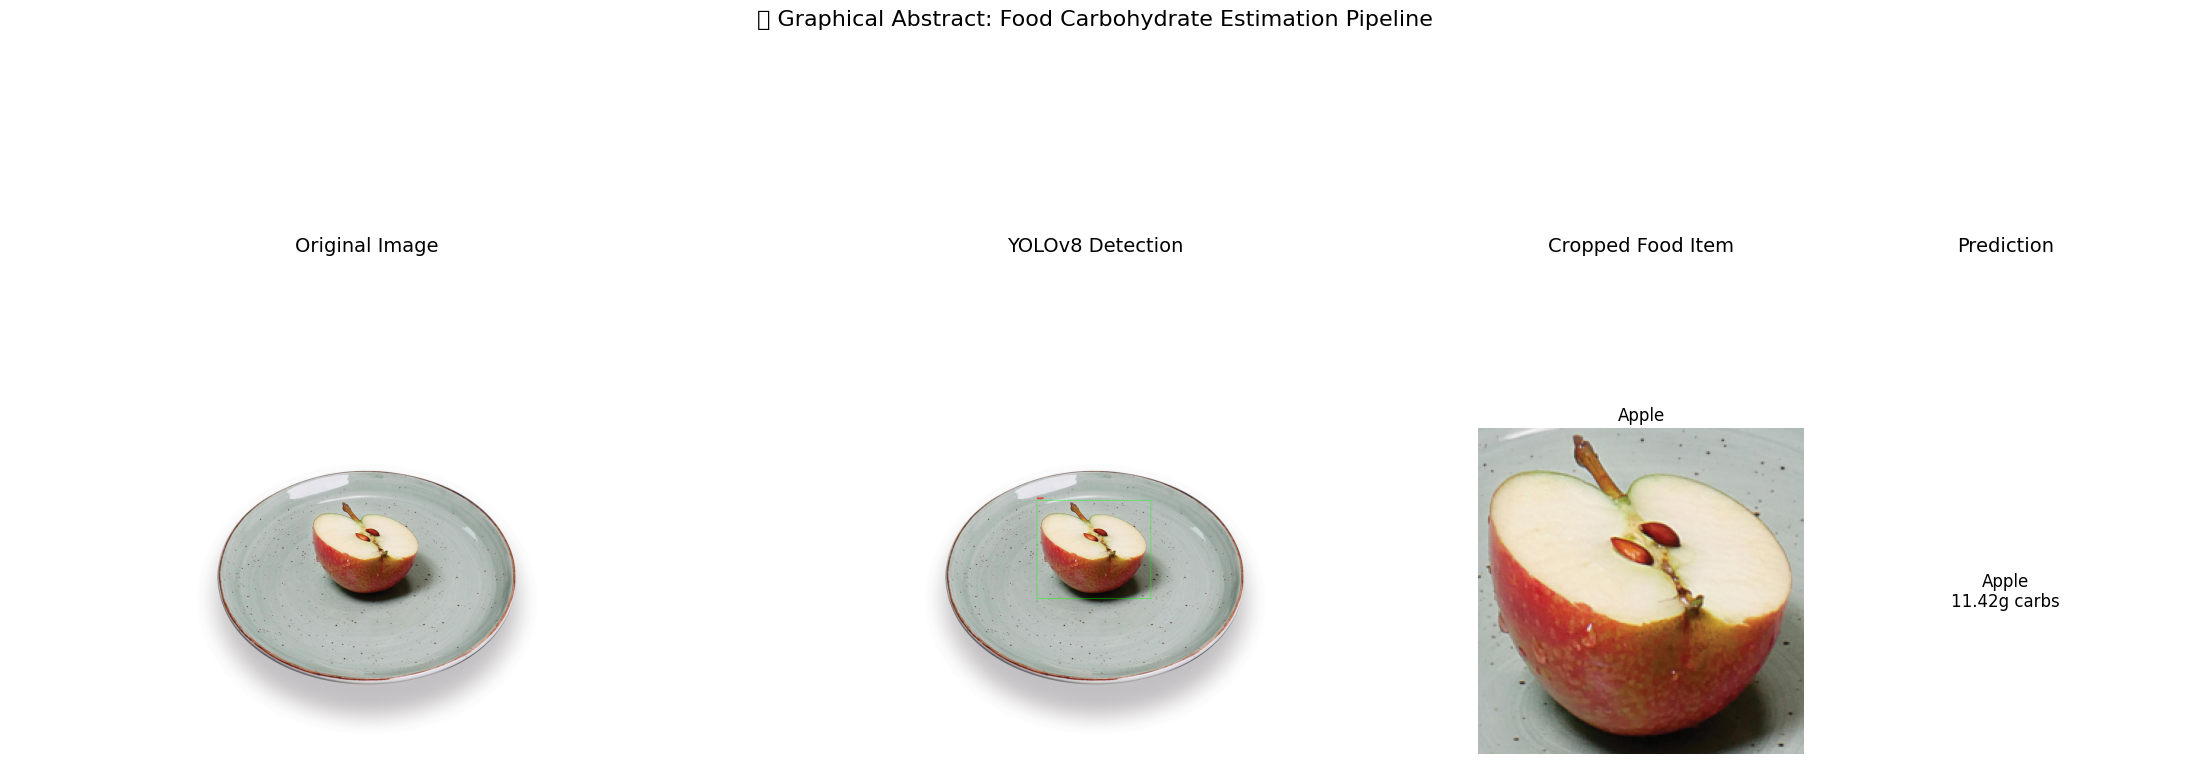

In [67]:
import matplotlib.pyplot as plt
import cv2
import torch
import numpy as np

# Sample image to visualize pipeline
sample_image_path = "/home/aojwang/data/MergeDataset/images/1Apple.jpg" 
food_items = preprocess_image(sample_image_path, use_ground_truth=False)

# Reload trained model
MODEL_PATH = '/home/aojwang/data/model/food_weight_model.pth'
weight_model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
weight_model.eval()

# Load original image
original = cv2.cvtColor(cv2.imread(sample_image_path), cv2.COLOR_BGR2RGB)

# Get YOLO detections
results = yolo_model(original, verbose=False)
detections = results[0].boxes
annotated = original.copy()

# Annotate image with labels
for box in detections:
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    label = yolo_model.names[int(box.cls[0].item())]
    cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(annotated, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# Start plotting
num_items = len(food_items)
fig, axs = plt.subplots(num_items + 1, 4, figsize=(18, 4 * (num_items + 1)))
fig.suptitle("🔬 Graphical Abstract: Food Carbohydrate Estimation Pipeline", fontsize=16)

# First row (headers)
headers = ["Original Image", "YOLOv8 Detection", "Cropped Food Item", "Prediction"]
for i, title in enumerate(headers):
    axs[0, i].axis("off")
    axs[0, i].text(0.5, 0.5, title, fontsize=14, ha='center', va='center')

# Populate rows
for idx, (label, img_tensor, features, _) in enumerate(food_items):
    # Row index in plot
    row = idx + 1

    # Column 0 - Original
    axs[row, 0].imshow(original)
    axs[row, 0].axis('off')

    # Column 1 - Annotated
    axs[row, 1].imshow(annotated)
    axs[row, 1].axis('off')

    # Column 2 - Cropped item
    cropped_img = img_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)
    cropped_img = np.clip((cropped_img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]), 0, 1)
    axs[row, 2].imshow(cropped_img)
    axs[row, 2].set_title(f"{label}")
    axs[row, 2].axis('off')

    # Column 3 - Prediction
    with torch.no_grad():
        prediction = weight_model(img_tensor.to(device), features.to(device)).item()
    axs[row, 3].text(0.5, 0.5, f"{label}\n{prediction:.2f}g carbs", fontsize=12, ha='center', va='center')
    axs[row, 3].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# TODO
1. Augmentation test
2. Background removal
# Experiments:
- https://pmc.ncbi.nlm.nih.gov/articles/PMC11887021/
- https://arxiv.org/html/2405.16478v1
- https://onlinelibrary.wiley.com/doi/10.1155/2023/6612302